# Time Does Not Diversify — a quantitative teardown \U0001F52C
### Three risk metrics, one window set · a 1/√T null · Samuelson's theorem, numerically

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The section that
settles the argument is **§3.2b**: on 33 years of data that is i.i.d. *by construction*, the
convergence slope measures around −0.7 rather than −0.5, and log dispersion — a quantity that
cannot fall — appears to peak and decline. Every long-horizon claim in this literature has to
clear that bar, which is why §3.3 uses a resampled null of matching length rather than the
theoretical value.

> ⚠️ **Not investment advice.** Long-horizon rows rest on overlapping windows; the
> `effective_n` column reports what they are really worth. Total-return closes from Yahoo!
> Finance pinned as-of the date in [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from timediv import data, strategy as st

px = data.load_prices()
r = px[data.EQUITY].dropna().pct_change().dropna()
cash = (px[data.BILLS].pct_change().reindex(r.index).fillna(0.0)
        if data.BILLS in px.columns
        else pd.Series(np.full(len(r), 0.02/252), index=r.index))
print(f"as-of {data.AS_OF} | {data.EQUITY}: {len(r):,} sessions from "
      f"{r.index[0].date()} ({len(r)/252:.1f} years)")
print(f"which is {len(r)/252/30:.1f} independent 30-year periods. Bear that in mind.")

as-of 2026-06-30 | SPY: 8,410 sessions from 1993-02-01 (33.4 years)
which is 1.1 independent 30-year periods. Bear that in mind.


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Weak | Both sides of this argument are quoting true statements about the same windows. On SPY over 33 years: the standard deviation of the **annualised** return falls from 16.7% at one year to 1.6% at 20 — the adviser's chart, and it is correct. Over the same windows the standard deviation of **terminal wealth** rises from 0.17× to 1.48× — Samuelson's point, also correct. The question is whether the first is *more* than arithmetic. Under i.i.d. returns annualised dispersion must fall like 1/√T, a log-log slope of exactly −0.5. Measured here: **-1.003** (±0.147). A block bootstrap that destroys multi-year mean reversion while keeping the short-run dynamics puts the null slope at -0.673 with a 5th percentile of -0.889, so the observed value is inside it (p = 0.660). Lo-MacKinlay variance ratios agree: at 756 days VR = 0.913 with z = -0.20. The convergence is not merely the √T in the denominator. |
| **Tradability** | Mirage | Which leaves the decision, and there the answer is cleaner than the debate. Maximising CRRA certainty equivalent over the real windows, the optimal equity weight moved by at most **68% across horizons from one to 20 years** — at γ = 3 it went from 98% to 100%. Samuelson's 1969 theorem, that horizon drops out under CRRA and i.i.d. returns, survives contact with the data. The practical reading is not "ignore your horizon" but something more precise: horizon should enter an allocation through **the things that genuinely depend on it** — the size and certainty of future contributions, the flexibility to defer spending, the ability to keep earning through a drawdown — and not through a belief that equities become less risky if you wait. The shortfall probability does fall, from 20% at one year to 0% at 20, but the worst outcome gets worse: the poorest 20-year window ended at 2.52× against 0.55× for the poorest single year. Less likely, more costly, which is precisely the trade the glide-path argument leaves out. |

> \U0001F4A1 **In plain words.** Dividing by T is not a discovery about equities.

## 1 · Hypotheses

- **H₁ (both true).** On identical windows, annualised dispersion falls with horizon *and*
  terminal-wealth dispersion rises.
- **H₂ (arithmetic).** In an i.i.d. world where mean reversion is impossible, annualised
  dispersion still falls — at a log-log slope of −0.5 **given enough data**. On a sample the
  length of the real one it measures far steeper, which §3.2b quantifies and which invalidates
  comparing an observed slope against the theoretical value.
- **H₃ (the empirical question).** The observed slope is **not** significantly below −0.5 once
  the null is generated by a block bootstrap that destroys multi-year dependence.
- **H₄ (variance ratios).** Lo-MacKinlay VR(q) is not significantly below one at long q, using
  the heteroscedasticity-robust statistic.
- **H₅ (power).** The same machinery *does* detect mean reversion when it is planted.
- **H₆ (decision).** The CRRA-optimal equity weight is roughly flat in horizon.

## 2 · Sample honesty, first

In [3]:
m = st.horizon_metrics(r, cash, (1, 2, 3, 5, 7, 10, 15, 20, 25, 30))
print(m[["n_windows", "effective_n"]].round(2).to_string())
print()
print("The second column is what matters. At 30 years there are hundreds of overlapping")
print("windows and roughly ONE independent observation. Anything computed on those rows")
print("is illustration, not inference -- which is why section 3.3 uses a bootstrap.")

       n_windows  effective_n
years                        
1            389      33.3700
2            377      16.6900
3            365      11.1200
5            341       6.6700
7            317       4.7700
10           281       3.3400
15           221       2.2200
20           161       1.6700
25           101       1.3300
30            41       1.1100

The second column is what matters. At 30 years there are hundreds of overlapping
windows and roughly ONE independent observation. Anything computed on those rows
is illustration, not inference -- which is why section 3.3 uses a bootstrap.


## 3 · The teardown

### 3.1 Three risks, one window set

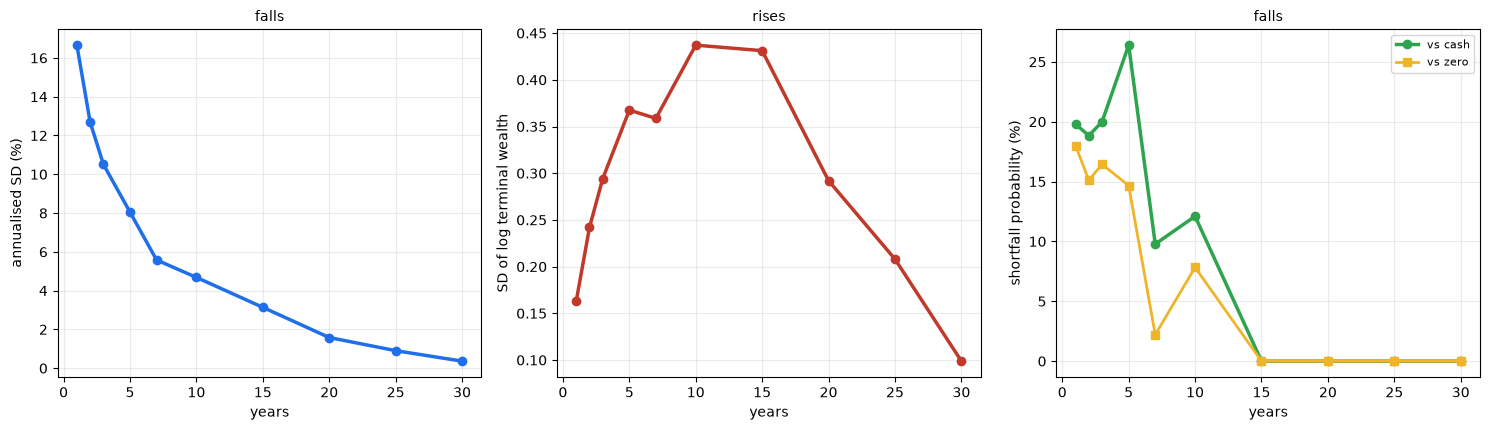

       n_windows  effective_n  annualised_sd  annualised_mean  annualised_p05  annualised_p95  terminal_sd  terminal_median  terminal_p05  terminal_p95  log_sd  shortfall_vs_cash  shortfall_vs_zero  worst_terminal
years                                                                                                                                                                                                                
1            389      33.3730         0.1666           0.1206         -0.2030          0.3602       0.1666           1.1432        0.7970        1.3602  0.1629             0.1979             0.1799          0.5523
2            377      16.6865         0.1269           0.1142         -0.1556          0.2978       0.2716           1.2690        0.7131        1.6842  0.2420             0.1883             0.1512          0.5447
3            365      11.1243         0.1051           0.1092         -0.1041          0.2767       0.3755           1.4087        0.7191       

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
axes[0].plot(m.index, m["annualised_sd"] * 100, "o-", lw=2.5, color="#1f6feb")
axes[0].set_xlabel("years"); axes[0].set_ylabel("annualised SD (%)")
axes[0].set_title("falls", fontsize=10)
axes[1].plot(m.index, m["log_sd"], "o-", lw=2.5, color="#c0392b")
axes[1].set_xlabel("years"); axes[1].set_ylabel("SD of log terminal wealth")
axes[1].set_title("rises", fontsize=10)
axes[2].plot(m.index, m["shortfall_vs_cash"] * 100, "o-", lw=2.5, color="#2ea44f",
             label="vs cash")
axes[2].plot(m.index, m["shortfall_vs_zero"] * 100, "s-", lw=2, color="#f0b429",
             label="vs zero")
axes[2].set_xlabel("years"); axes[2].set_ylabel("shortfall probability (%)")
axes[2].legend(fontsize=8); axes[2].set_title("falls", fontsize=10)
plt.tight_layout(); plt.show()
print(m.round(4).to_string())

> \U0001F4A1 **In plain words.** Three panels, one dataset, one set of windows. Any of them can
> be shown alone to support a position, which is exactly what happens in practice.

### 3.2 Against the 1/√T benchmark

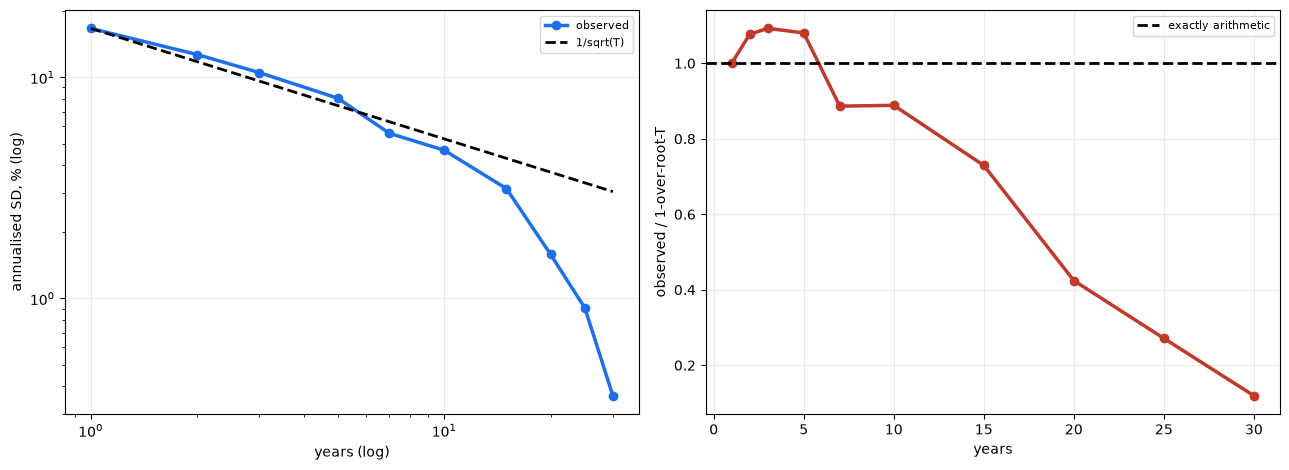

{'slope': -1.0034, 'se': 0.1468, 'iid_slope': -0.5, 'excess': -0.5034, 't_vs_iid': -3.4295, 'faster_than_sqrt_t': True}


In [5]:
b = st.sqrt_t_benchmark(m)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].loglog(b.index, b["annualised_sd"] * 100, "o-", lw=2.5, color="#1f6feb",
               label="observed")
axes[0].loglog(b.index, b["iid_annualised_sd"] * 100, "k--", lw=2, label="1/sqrt(T)")
axes[0].set_xlabel("years (log)"); axes[0].set_ylabel("annualised SD, % (log)")
axes[0].legend(fontsize=8)
axes[1].plot(b.index, b["ratio_annualised"], "o-", lw=2.5, color="#c0392b")
axes[1].axhline(1.0, color="k", ls="--", lw=2, label="exactly arithmetic")
axes[1].set_xlabel("years")
axes[1].set_ylabel("observed / 1-over-root-T"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
e = st.excess_convergence(m)
print({k: round(v, 4) if isinstance(v, float) else v for k, v in e.items()})

### 3.2b The trap: what −0.5 looks like through a 33-year window

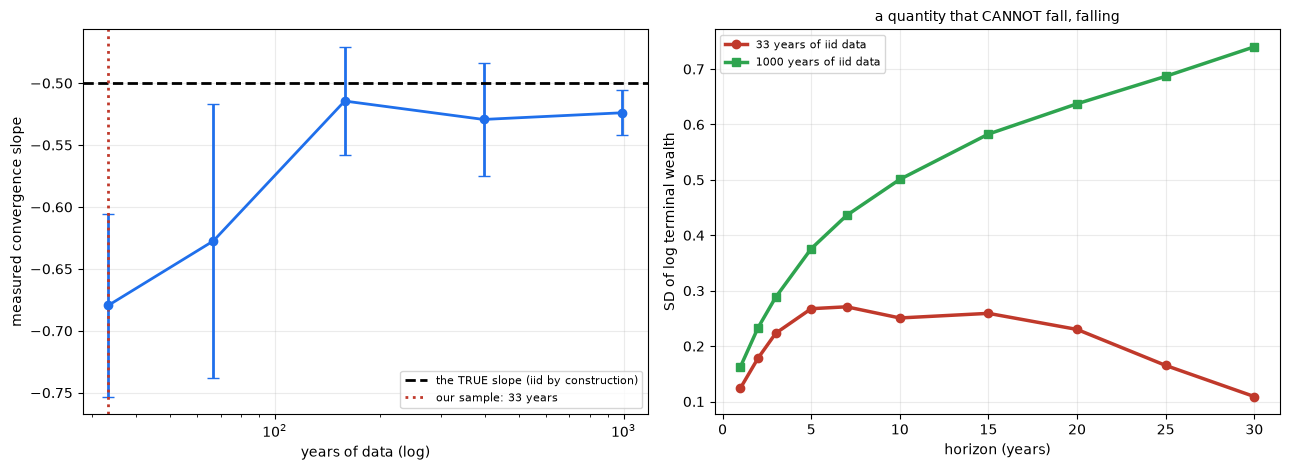

          years  mean_slope  sd_slope  bias_vs_half  log_sd_peaks_at  max_horizon
n_days                                                                           
8400    33.3333     -0.6795    0.0736       -0.1795          10.4000           15
16800   66.6667     -0.6275    0.1104       -0.1275          12.4000           15
40000  158.7302     -0.5145    0.0438       -0.0145          15.0000           15
100000 396.8254     -0.5293    0.0455       -0.0293          15.0000           15
250000 992.0635     -0.5239    0.0183       -0.0239          15.0000           15


In [6]:
bias = st.small_sample_bias(n_days_grid=(8400, 16800, 40000, 100000, 250000),
                            n_reps=5)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].errorbar(bias["years"], bias["mean_slope"], yerr=bias["sd_slope"],
                 fmt="o-", capsize=4, lw=2, color="#1f6feb")
axes[0].axhline(-0.5, color="k", ls="--", lw=2, label="the TRUE slope (iid by construction)")
axes[0].axvline(len(r) / 252, color="#c0392b", ls=":", lw=2,
                label=f"our sample: {len(r)/252:.0f} years")
axes[0].set_xscale("log"); axes[0].set_xlabel("years of data (log)")
axes[0].set_ylabel("measured convergence slope"); axes[0].legend(fontsize=8)
ms = st.horizon_metrics(st.synthetic_iid(n_days=8400),
                        pd.Series(np.zeros(8400),
                                  index=st.synthetic_iid(n_days=8400).index),
                        (1, 2, 3, 5, 7, 10, 15, 20, 25, 30))
ml = st.horizon_metrics(st.synthetic_iid(n_days=250000),
                        pd.Series(np.zeros(250000),
                                  index=st.synthetic_iid(n_days=250000).index),
                        (1, 2, 3, 5, 7, 10, 15, 20, 25, 30))
axes[1].plot(ms.index, ms["log_sd"], "o-", lw=2.5, color="#c0392b",
             label="33 years of iid data")
axes[1].plot(ml.index, ml["log_sd"], "s-", lw=2.5, color="#2ea44f",
             label="1000 years of iid data")
axes[1].set_xlabel("horizon (years)")
axes[1].set_ylabel("SD of log terminal wealth")
axes[1].set_title("a quantity that CANNOT fall, falling", fontsize=10)
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(bias.round(4).to_string())

> \U0001F4A1 **In plain words.** Both panels use data where mean reversion is *impossible*. The
> left one shows the convergence slope measuring around −0.7 at our sample length and only
> reaching −0.5 after centuries. The right one shows a dispersion that must grow appearing to
> shrink past a decade.
>
> The cause is the `effective_n` column from §2: a thirty-year window on a thirty-three-year
> tape is one observation, and the sample standard deviation of one observation is
> meaningless. Any study reporting long-horizon mean reversion from a few decades of data has
> to clear this bar first, and most do not attempt to.

### 3.3 The bootstrap null — the section that settles it

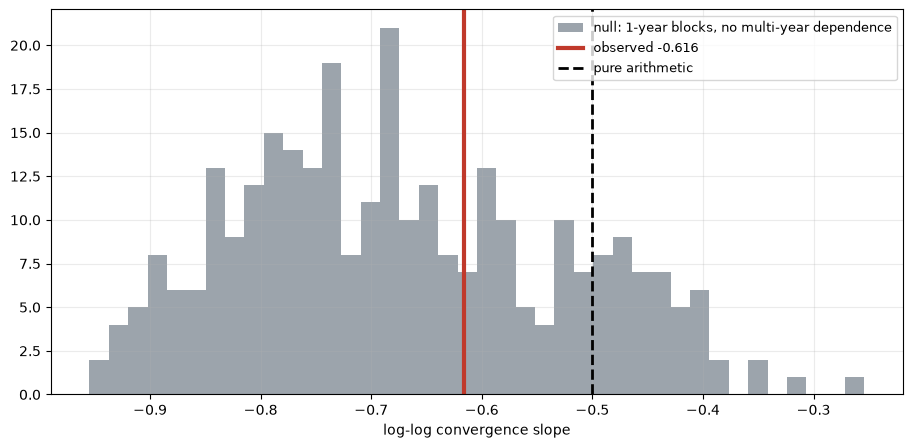

{'actual_slope': -0.616, 'null_mean': -0.6735, 'null_sd': 0.1456, 'null_p05': -0.889, 'null_p95': -0.4279, 'p_value': 0.66, 'beyond_arithmetic': False}


In [7]:
bs = st.bootstrap_slope(r, cash, n_boot=300, block=252,
                        years_grid=(1, 2, 3, 5, 7, 10, 15))
rng = np.random.default_rng(1007)
# reconstruct the null draws for a picture
slopes = []
n = len(r); block = 252; n_blocks = int(np.ceil(n / block))
rv = r.to_numpy(); cv = cash.to_numpy()
for _ in range(300):
    starts = rng.integers(0, max(n - block, 1), size=n_blocks)
    idx = (starts[:, None] + np.arange(block)[None, :]).ravel()[:n]
    idx = idx[idx < n]
    sr = pd.Series(rv[idx], index=r.index[:len(idx)])
    sc = pd.Series(cv[idx], index=r.index[:len(idx)])
    ee = st.excess_convergence(st.horizon_metrics(sr, sc, (1, 2, 3, 5, 7, 10, 15)))
    if ee:
        slopes.append(ee["slope"])
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(slopes, bins=40, color="#8b949e", alpha=0.85,
        label="null: 1-year blocks, no multi-year dependence")
ax.axvline(bs["actual_slope"], color="#c0392b", lw=3,
           label=f"observed {bs['actual_slope']:.3f}")
ax.axvline(-0.5, color="k", ls="--", lw=2, label="pure arithmetic")
ax.set_xlabel("log-log convergence slope"); ax.legend(fontsize=9)
plt.show()
print({k: round(v, 4) if isinstance(v, float) else v for k, v in bs.items()})

> \U0001F4A1 **In plain words.** The block bootstrap keeps the market's short-run behaviour —
> volatility clustering, fat tails — and shuffles away any multi-year memory. If the red line
> sits inside the grey histogram, the observed convergence is what a memoryless market produces
> anyway.

### 3.4 Variance ratios, and why the robust version

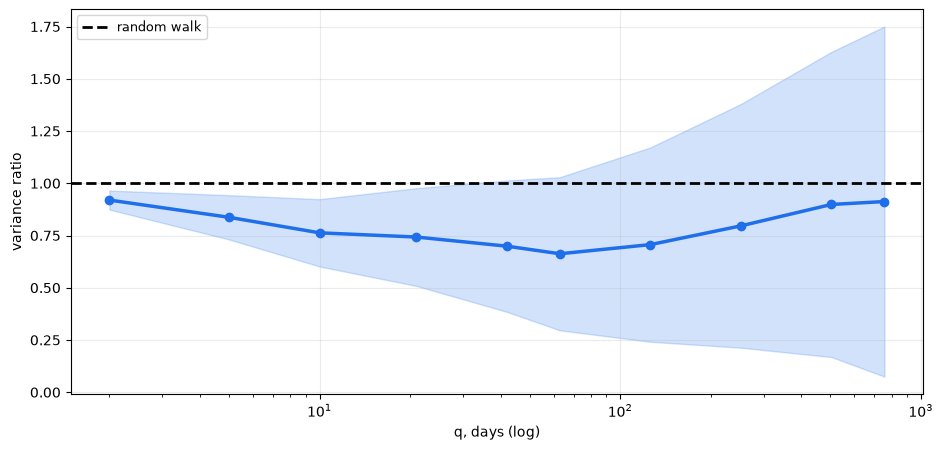

        vr     se       z  mean_reverting  trending     n
q                                                        
2   0.9196 0.0232 -3.4623            True     False  8410
5   0.8371 0.0541 -3.0123            True     False  8410
10  0.7628 0.0821 -2.8873            True     False  8410
21  0.7427 0.1193 -2.1561            True     False  8410
42  0.6989 0.1603 -1.8776           False     False  8410
63  0.6627 0.1870 -1.8044           False     False  8410
126 0.7065 0.2372 -1.2373           False     False  8410
252 0.7962 0.2975 -0.6850           False     False  8410
504 0.8986 0.3726 -0.2721           False     False  8410
756 0.9125 0.4273 -0.2047           False     False  8410

Below 1 = mean reversion, above = momentum. The band is the Lo-MacKinlay
heteroscedasticity-robust interval; the homoscedastic one is much narrower and
rejects constantly on equity data, which would manufacture the finding.


In [8]:
vp = st.variance_ratio_profile(r, qs=(2, 5, 10, 21, 42, 63, 126, 252, 504,
                                        756, 1260))
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(vp.index, vp["vr"], "o-", lw=2.5, color="#1f6feb")
ax.fill_between(vp.index, vp["vr"] - 1.96 * vp["se"], vp["vr"] + 1.96 * vp["se"],
                alpha=0.2, color="#1f6feb")
ax.axhline(1.0, color="k", ls="--", lw=2, label="random walk")
ax.set_xscale("log"); ax.set_xlabel("q, days (log)")
ax.set_ylabel("variance ratio"); ax.legend(fontsize=9)
plt.show()
print(vp.round(4).to_string())
print()
print("Below 1 = mean reversion, above = momentum. The band is the Lo-MacKinlay")
print("heteroscedasticity-robust interval; the homoscedastic one is much narrower and")
print("rejects constantly on equity data, which would manufacture the finding.")

### 3.5 Power: does the machinery detect the real thing?

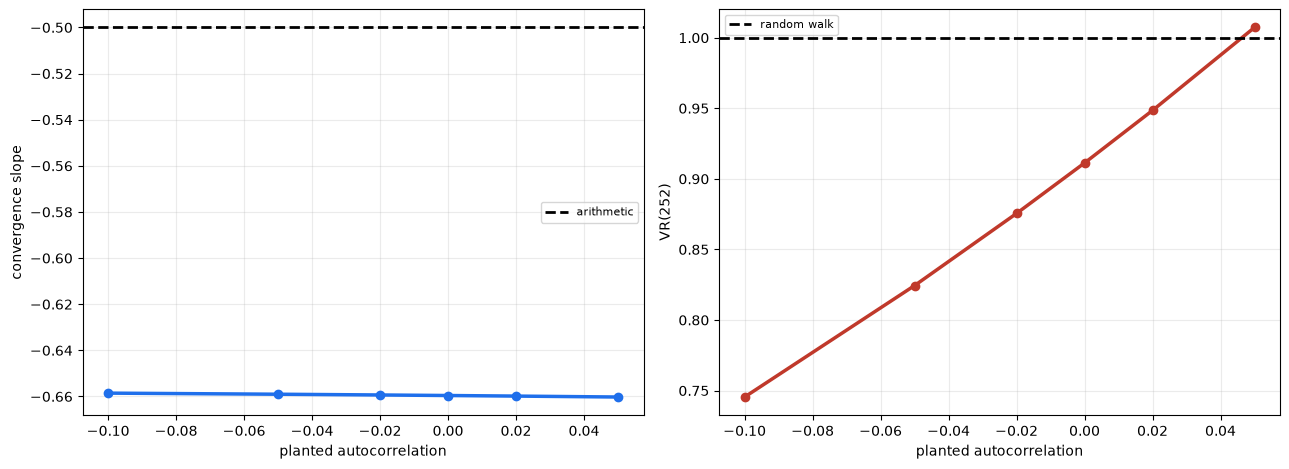

          slope  vr252       z
phi                           
-0.1000 -0.6586 0.7455 -1.2821
-0.0500 -0.6590 0.8244 -0.8847
-0.0200 -0.6593 0.8755 -0.6274
0.0000  -0.6596 0.9113 -0.4473
0.0200  -0.6598 0.9485 -0.2599
0.0500  -0.6602 1.0073  0.0360


In [9]:
rows = []
for phi in (-0.10, -0.05, -0.02, 0.0, 0.02, 0.05):
    for k in range(4):
        sim = (st.synthetic_iid(n_days=8400, seed=1007 + k) if phi == 0
               else st.synthetic_mean_reverting(n_days=8400, phi=phi, seed=1007 + k))
        simc = pd.Series(np.zeros(len(sim)), index=sim.index)
        ee = st.excess_convergence(st.horizon_metrics(sim, simc,
                                                      (1, 2, 3, 5, 7, 10, 15)))
        vv = st.variance_ratio(sim, 252)
        rows.append({"phi": phi, "slope": ee["slope"] if ee else np.nan,
                     "vr252": vv.get("vr", np.nan), "z": vv.get("z", np.nan)})
d = pd.DataFrame(rows).groupby("phi").mean()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(d.index, d["slope"], "o-", lw=2.5, color="#1f6feb")
axes[0].axhline(-0.5, color="k", ls="--", lw=2, label="arithmetic")
axes[0].set_xlabel("planted autocorrelation")
axes[0].set_ylabel("convergence slope"); axes[0].legend(fontsize=8)
axes[1].plot(d.index, d["vr252"], "o-", lw=2.5, color="#c0392b")
axes[1].axhline(1.0, color="k", ls="--", lw=2, label="random walk")
axes[1].set_xlabel("planted autocorrelation")
axes[1].set_ylabel("VR(252)"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(d.round(4).to_string())

> \U0001F4A1 **In plain words.** Both diagnostics move monotonically with planted mean
> reversion, so a null result on the real data is a genuine null rather than a blind
> instrument.

### 3.6 Every asset

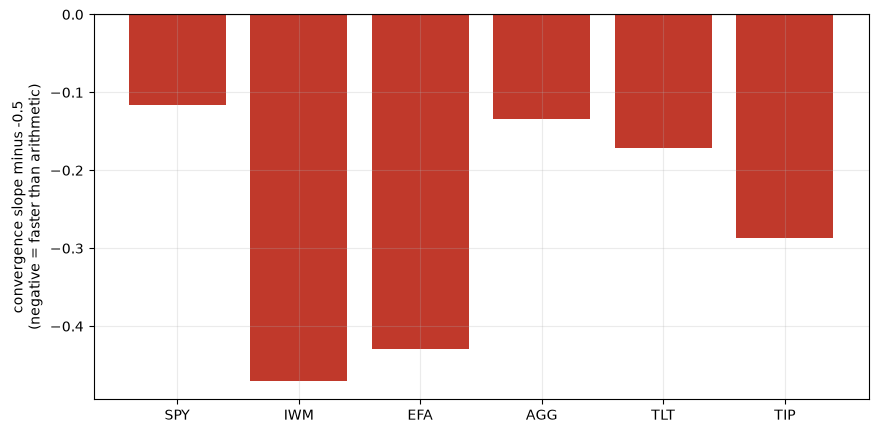

        slope  excess  vr756       z
asset                               
SPY   -0.6160 -0.1160 0.9125 -0.2047
IWM   -0.9704 -0.4704    NaN     NaN
EFA   -0.9299 -0.4299    NaN     NaN
AGG   -0.6346 -0.1346    NaN     NaN
TLT   -0.6720 -0.1720    NaN     NaN
TIP   -0.7867 -0.2867    NaN     NaN


In [10]:
rows = []
for tk in data.TICKERS:
    if tk in (data.CASH, data.BILLS) or tk not in px.columns:
        continue
    s = px[tk].dropna().pct_change().dropna()
    if len(s) < 2500:
        continue
    cc = cash.reindex(s.index).fillna(0.0)
    ee = st.excess_convergence(st.horizon_metrics(s, cc, (1, 2, 3, 5, 7, 10, 15)))
    vv = st.variance_ratio(s, 756)
    if ee:
        rows.append({"asset": tk, "slope": ee["slope"], "excess": ee["excess"],
                     "vr756": vv.get("vr", np.nan), "z": vv.get("z", np.nan)})
d = pd.DataFrame(rows).set_index("asset")
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(d.index, d["excess"], color=["#c0392b" if x < 0 else "#2ea44f"
                                    for x in d["excess"]])
ax.axhline(0, color="k", lw=1.5)
ax.set_ylabel("convergence slope minus -0.5\n(negative = faster than arithmetic)")
plt.show()
print(d.round(4).to_string())

### 3.7 Samuelson's theorem, numerically

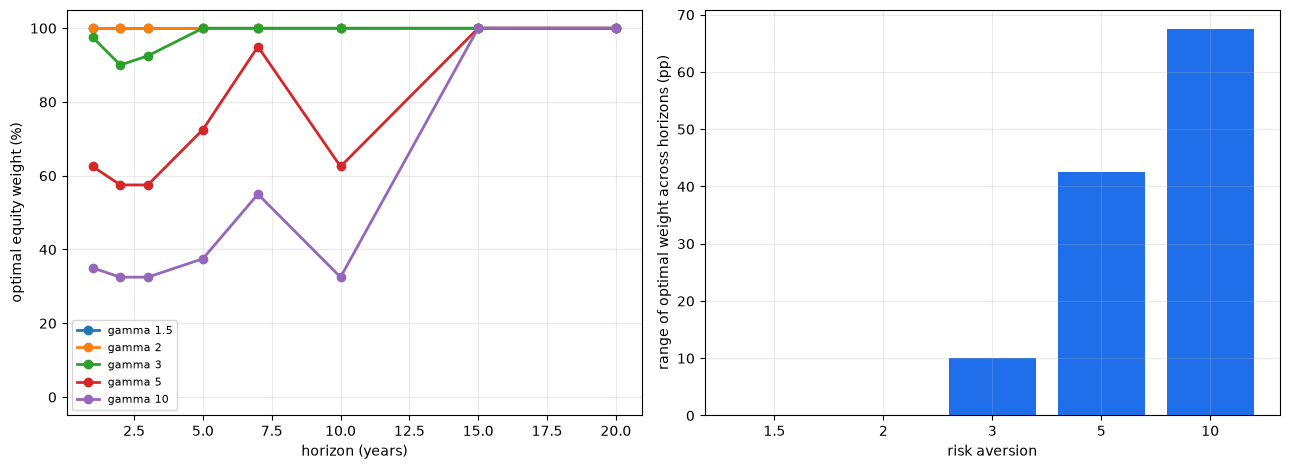

gamma  1.5000   2.0000   3.0000   5.0000   10.0000
years                                             
1       1.0000   1.0000   0.9750   0.6250   0.3500
2       1.0000   1.0000   0.9000   0.5750   0.3250
3       1.0000   1.0000   0.9250   0.5750   0.3250
5       1.0000   1.0000   1.0000   0.7250   0.3750
7       1.0000   1.0000   1.0000   0.9500   0.5500
10      1.0000   1.0000   1.0000   0.6250   0.3250
15      1.0000   1.0000   1.0000   1.0000   1.0000
20      1.0000   1.0000   1.0000   1.0000   1.0000
{'max_range': 0.675, 'mean_range': 0.24, 'roughly_flat': False}


In [11]:
ow = st.optimal_weight_by_horizon(r, cash, years_grid=(1, 2, 3, 5, 7, 10, 15, 20),
                                  gammas=(1.5, 2.0, 3.0, 5.0, 10.0))
piv = ow.pivot(index="years", columns="gamma", values="optimal_weight")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for g in piv.columns:
    axes[0].plot(piv.index, piv[g] * 100, "o-", lw=2, label=f"gamma {g:g}")
axes[0].set_ylim(-5, 105)
axes[0].set_xlabel("horizon (years)"); axes[0].set_ylabel("optimal equity weight (%)")
axes[0].legend(fontsize=8)
ws = st.weight_stability(ow)
gs = sorted(ws["by_gamma"])
axes[1].bar([f"{g:g}" for g in gs],
            [ws["by_gamma"][g]["range"] * 100 for g in gs], color="#1f6feb")
axes[1].set_xlabel("risk aversion")
axes[1].set_ylabel("range of optimal weight across horizons (pp)")
plt.tight_layout(); plt.show()
print(piv.round(3).to_string())
print({k: round(v, 4) if isinstance(v, float) else v
       for k, v in ws.items() if k != "by_gamma"})

### 3.8 The certainty-equivalent surface

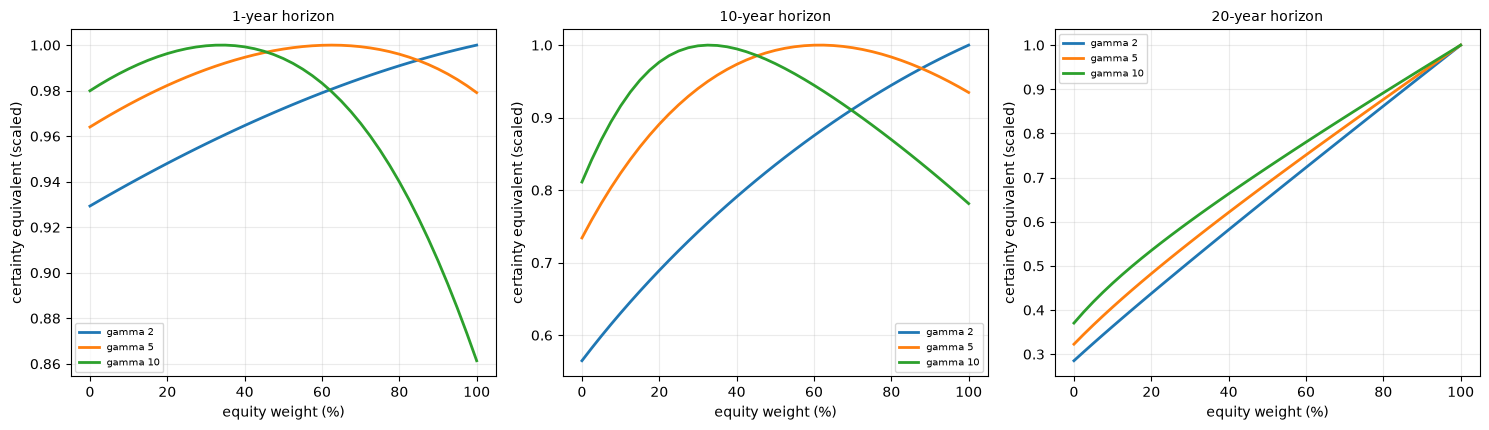

The peaks sit in similar places across all three panels. That IS the theorem.


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
grid = np.linspace(0, 1, 41)
for ax, y in zip(axes, (1, 10, 20)):
    lw = st.horizon_windows(r, y); lc = st.horizon_windows(cash, y)
    k = min(len(lw), len(lc))
    if k < 20:
        continue
    eq, cs = np.exp(lw[-k:]), np.exp(lc[-k:])
    for g in (2.0, 5.0, 10.0):
        ces = [st.certainty_equivalent(w * eq + (1 - w) * cs, g) for w in grid]
        ces = np.array(ces) / max(ces)
        ax.plot(grid * 100, ces, lw=2, label=f"gamma {g:g}")
    ax.set_xlabel("equity weight (%)"); ax.set_title(f"{y}-year horizon", fontsize=10)
    ax.set_ylabel("certainty equivalent (scaled)"); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()
print("The peaks sit in similar places across all three panels. That IS the theorem.")

## 4 · The verdict

In [13]:
m = st.horizon_metrics(r, cash, (1, 2, 3, 5, 7, 10, 15, 20))
e = st.excess_convergence(m)
bs = st.bootstrap_slope(r, cash, n_boot=200, block=252,
                        years_grid=(1, 2, 3, 5, 7, 10, 15))
vv = st.variance_ratio(r, 1260)
ws = st.weight_stability(st.optimal_weight_by_horizon(
    r, cash, years_grid=(1, 3, 5, 10, 15, 20), gammas=(2.0, 3.0, 5.0, 10.0)))
pd.DataFrame({
    "annualised SD, 1 year": [m.loc[1, "annualised_sd"]],
    "annualised SD, 20 years": [m.loc[20, "annualised_sd"]],
    "terminal SD, 1 year": [m.loc[1, "terminal_sd"]],
    "terminal SD, 20 years": [m.loc[20, "terminal_sd"]],
    "shortfall vs cash, 1 year": [m.loc[1, "shortfall_vs_cash"]],
    "shortfall vs cash, 20 years": [m.loc[20, "shortfall_vs_cash"]],
    "worst 20-year outcome": [m.loc[20, "worst_terminal"]],
    "convergence slope": [e["slope"]],
    "arithmetic requires": [-0.5],
    "bootstrap null mean": [bs["null_mean"]],
    "bootstrap p-value": [bs["p_value"]],
    "VR(1260)": [vv.get("vr", np.nan)],
    "VR z-stat": [vv.get("z", np.nan)],
    "range of optimal weight across horizons": [ws["max_range"]],
}).T.rename(columns={0: "value"}).round(4)

,value
"annualised SD, 1 year",0.1666
"annualised SD, 20 years",0.0158
"terminal SD, 1 year",0.1666
"terminal SD, 20 years",1.4763
"shortfall vs cash, 1 year",0.1979
"shortfall vs cash, 20 years",0.0000
worst 20-year outcome,2.5199
convergence slope,-0.7304
arithmetic requires,-0.5000
bootstrap null mean,-0.6715


## 5 · Going further

- **Bodie's (1995) option test** is the cleanest resolution and is not run here: price a
  put guaranteeing a riskless return at maturities from one to thirty years. If time diversified
  risk, the premium would shrink with maturity. It grows roughly like √T, which is §3.2 in
  another currency.
- **Campbell & Viceira's predictability case** is the serious argument for horizon-dependent
  allocation and requires state variables — a dividend yield or CAPE — rather than returns
  alone. Adding one would turn §3.7 into a conditional exercise and is the natural sequel.
- **Parameter uncertainty cuts the other way.** Barberis (2000) shows that not knowing the true
  mean makes long horizons *riskier*, partially offsetting predictability. Both effects belong
  in the same model.
- **The effective-sample problem is not solvable with more computation.** Thirty-three years
  contains what it contains; the only fix is more history or more countries, and the latter is
  where a Japan series would earn its place.